---
title: 'Expected Performance of a Mean-Reversion Trading Strategy — Part 6'
date: 2026-03-16
description: "How does a time-varying fair value affect the Sharpe ratio of a mean-reversion strategy?"
categories: [Quantitative Finance, Trading Strategies, Stochastic Processes]
content-type: "series"
series-id: "mean-reversion-strategy"
series-title: "Expected Performance of a Mean-Reversion Trading Strategy"
series-part: 6
project-ids: [mean-reversion-strategy]
---

Parts 1–5 of this series analysed the performance of a mean-reversion strategy under a single, powerful simplification: the asset's fair value $v$ was held constant. Every price change was therefore a change in mispricing, and the trader's only challenge was to estimate the level $v$ from noisy data.

In practice, fair value itself moves — driven by fundamentals, regime shifts, or slow-moving macroeconomic factors. When it does, the price signal $p_t = v_t + X_t$ conflates two distinct sources of variation: fast mean-reverting mispricing $X_t$ (which the strategy profits from) and slow fair-value drift $v_t$ (which it does not). A trailing estimator like the EMA cannot distinguish the two, and this creates a new penalty channel that has no analogue in Parts 1–5.

This post develops the two-scale OU model — mispricing reverts fast, fair value reverts slowly — and derives the modified Sharpe ratio formulas. The key results are:

- An **irreducible penalty** $1/\sqrt{1 + \sigma_v^2/\sigma^2}$ that applies even with perfect information, reflecting the trader's unavoidable exposure to fair-value noise.
- A **two-term PnL decomposition**: profit from mispricing mean-reversion minus loss from mistakenly trading fair-value movements.
- A **viability condition** $\theta\sigma^2 > \theta_v\sigma_v^2$: the strategy is profitable only when mispricing mean-reversion is fast enough relative to fair-value variation.
- A preview of the **Kalman filter** as the optimal linear estimator for separating the two signals.

In [1]:
#| echo: false
#| output: false
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, linalg

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

rng = np.random.default_rng(42)


def simulate_two_scale_ou(theta, theta_v, sigma, sigma_v, lam, T, dt, n_paths, rng=rng):
    """Joint simulation of two-scale OU + EMA system.

    du = -theta_v * u dt + sigma_v dW^v       (fair-value deviation)
    dX = -theta * X dt + sigma dW              (mispricing)
    dM = (theta_v * u + lam * X - lam * M) dt - sigma_v dW^v  (EMA bias)

    Returns (u, X, M) arrays of shape (n_paths, n_steps+1).
    """
    n_steps = int(T / dt)
    u = np.zeros((n_paths, n_steps + 1))  # v_t - v_bar
    X = np.zeros((n_paths, n_steps + 1))  # mispricing
    M = np.zeros((n_paths, n_steps + 1))  # EMA bias
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dWv = rng.standard_normal(n_paths) * sqrt_dt
        dW = rng.standard_normal(n_paths) * sqrt_dt
        u[:, i+1] = u[:, i] - theta_v * u[:, i] * dt + sigma_v * dWv
        X[:, i+1] = X[:, i] - theta * X[:, i] * dt + sigma * dW
        M[:, i+1] = M[:, i] + (theta_v * u[:, i] + lam * X[:, i] - lam * M[:, i]) * dt - sigma_v * dWv
    return u, X, M


def sr_ema_two_scale(theta, theta_v, sigma, sigma_v, lam):
    """Analytical asymptotic SR for EMA under two-scale OU model."""
    a = theta + lam
    b = theta_v + lam
    mu = theta * sigma**2 / (2 * a) - theta_v * sigma_v**2 / (2 * b)
    var_xtilde = sigma**2 / (2 * a) + sigma_v**2 / (2 * b)
    qv = (sigma**2 + sigma_v**2) * var_xtilde
    if qv <= 0 or mu <= 0:
        return 0.0
    return mu / np.sqrt(qv)


def sr_perfect_info(theta, sigma, sigma_v):
    """Irreducible SR with perfect information (knows X_t exactly)."""
    return np.sqrt(theta / 2) / np.sqrt(1 + sigma_v**2 / sigma**2)


def compute_sr_mc(u, X, M, sigma, sigma_v, dt, T):
    """Monte Carlo SR from simulated paths."""
    X_tilde = X[:, :-1] - M[:, :-1]
    dX = np.diff(X, axis=1)
    du = np.diff(u, axis=1)  # approximate dv
    dp = dX + du
    dY = -X_tilde * dp
    Y_T = np.sum(dY, axis=1)
    mean_pnl = np.mean(Y_T / T)
    qv = np.sum(dY**2, axis=1)
    mean_qv = np.mean(qv / T)
    if mean_qv <= 0:
        return 0.0
    return mean_pnl / np.sqrt(mean_qv)


def kalman_steady_state(theta, theta_v, sigma, sigma_v):
    """Steady-state Kalman filter error covariance for the two-scale OU system.

    Solves the continuous-time algebraic Riccati equation (CARE).
    Returns P (2x2 error covariance) and K (2x1 Kalman gain).
    """
    F = np.array([[-theta_v, 0], [0, -theta]])
    G = np.array([[sigma_v, 0], [0, sigma]])
    H = np.array([[1, 1]])  # observation: p = v + X = (u + v_bar) + X
    Q = G @ G.T  # state noise covariance
    # Observation is dp, with noise H @ G @ dW. The observation noise covariance is:
    R_obs = np.array([[sigma_v**2 + sigma**2]])  # scalar
    # Cross-covariance between state noise and observation noise:
    S_cross = G @ np.array([[sigma_v], [sigma]])  # = [[sigma_v^2], [sigma^2]]

    # Modified system for correlated noise:
    F_mod = F - S_cross @ np.linalg.inv(R_obs) @ H
    Q_mod = Q - S_cross @ np.linalg.inv(R_obs) @ S_cross.T

    # Solve CARE: F_mod @ P + P @ F_mod.T + Q_mod - P @ H.T @ R_obs^{-1} @ H @ P = 0
    try:
        P = linalg.solve_continuous_are(F_mod.T, H.T, Q_mod, R_obs)
    except Exception:
        P = np.eye(2) * 0.01  # fallback
    K = (P @ H.T + S_cross) @ np.linalg.inv(R_obs)
    return P, K


print("Helpers loaded.")

Helpers loaded.


# The Two-Scale OU Model

We generalise the Parts 1–5 framework by allowing fair value to follow its own mean-reverting process on a slow timescale:

$$dv_t = -\theta_v\,(v_t - \bar{v})\, dt + \sigma_v\, dW_t^v, \qquad dX_t = -\theta\, X_t\, dt + \sigma\, dW_t,$$

where $W^v \perp W$, $\theta_v > 0$ is the fair-value mean-reversion speed, $\bar{v}$ is the long-run fair value, and $\sigma_v > 0$ is the fair-value volatility. The mispricing $X_t = p_t - v_t$ follows the same OU process as before. Typically $\theta_v \ll \theta$: fair value moves slowly relative to mispricing.

The price dynamics become

$$dp_t = dv_t + dX_t = -\theta_v(v_t - \bar{v})\, dt - \theta X_t\, dt + \sigma_v\, dW_t^v + \sigma\, dW_t.$$

The trader's PnL from position $-\tilde{X}_t = -(X_t - M_t)$ now splits into two terms:

$$dY_t = -(X_t - M_t)\, dp_t = \underbrace{-(X_t - M_t)\, dX_t}_{\text{mean-reversion PnL (Parts 1–5)}} \;\underbrace{-\; (X_t - M_t)\, dv_t}_{\text{fair-value drift exposure (new)}}.$$

The first term is the familiar mean-reversion profit. The second term is new: the trader's position is exposed to fair-value movements. Since the EMA bias $M_t$ is correlated with $v_t$ (through the lagged tracking), this second term has nonzero expectation and creates an additional penalty.

Three dimensionless parameters govern the new model: the timescale ratio $\theta_v/\theta$, the noise ratio $\rho = \sigma_v/\sigma$, and the EMA bandwidth $\lambda/\theta$.

# Irreducible Penalty from Fair-Value Noise

Even if the trader has perfect information — observing $X_t$ directly and trading with $M = 0$ — the fair-value noise imposes an irreducible penalty. With position $-X_t$:

$$dY_t = -X_t\,(dX_t + dv_t).$$

The expected PnL rate is unaffected: $\mathbb{E}[-X_t\, dv_t/dt] = -\theta_v\,\mathbb{E}[X_t\, u_t] = 0$ because $X_t$ and $u_t = v_t - \bar{v}$ are driven by independent Brownian motions. The expected PnL remains $\sigma^2/2$.

However, the quadratic variation increases. Since $dW \perp dW^v$:

$$d\langle Y\rangle_t = X_t^2\,(\sigma^2 + \sigma_v^2)\, dt.$$

The asymptotic QV rate is $(\sigma^2 + \sigma_v^2)\, s_\infty^2$ where $s_\infty^2 = \sigma^2/(2\theta)$. Therefore:

$$\boxed{\mathrm{SR}_\infty^{\text{perfect}} = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \sigma_v^2/\sigma^2}}.}$$

This has the same functional form as Part 2's bias penalty, but here the penalty is **irreducible**: it cannot be mitigated by better estimation, since it arises from the trader's position being exposed to the orthogonal fair-value noise. The ratio $\rho = \sigma_v/\sigma$ plays the role of a signal-to-noise ratio: when fair-value volatility dominates ($\rho \gg 1$), most of the price variation is uninformative, and the Sharpe ratio collapses.

@fig-irreducible verifies this formula and shows the penalty surface over $(\theta_v/\theta, \sigma_v/\sigma)$. Note that the irreducible penalty depends only on $\rho$, not on $\theta_v$ — the speed at which fair value reverts is irrelevant when information is perfect.

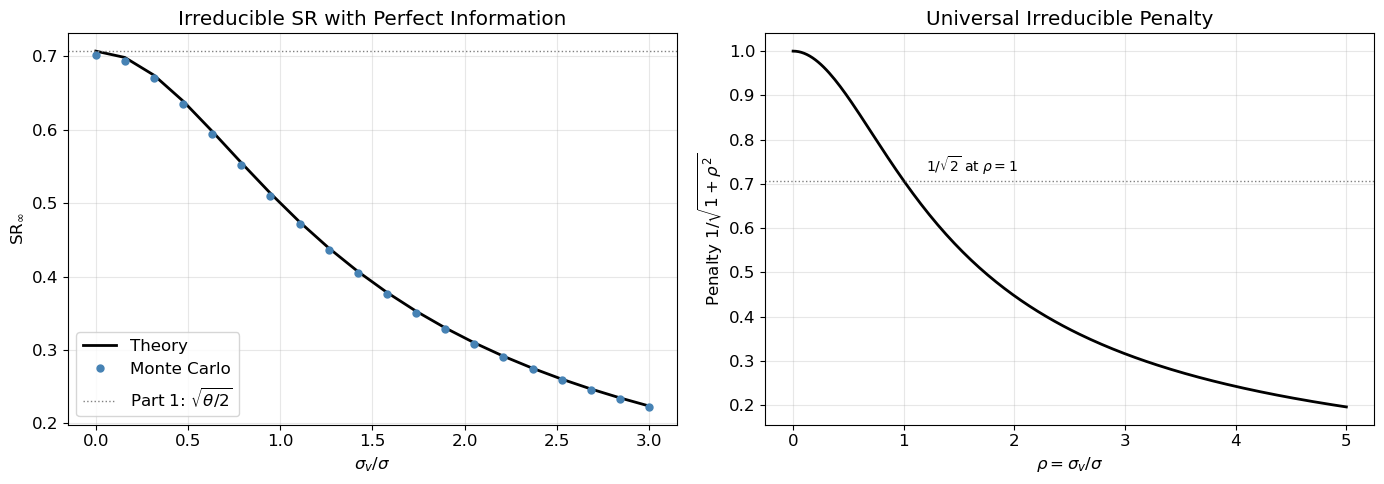

In [2]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-irreducible
#| fig-cap: 'Irreducible penalty from fair-value noise. Left: SR vs $\sigma_v/\sigma$ with perfect information ($M=0$), comparing theory to Monte Carlo. Right: the penalty factor $1/\sqrt{1+\rho^2}$ as a universal curve.'
# --- Experiment 1: Irreducible fair-value penalty ---
theta, sigma = 1.0, 0.10
theta_v = 0.2
T, dt, n_paths = 100, 1 / 252, 3_000

rho_scan = np.linspace(0, 3.0, 20)
sr_theory_perf = [sr_perfect_info(theta, sigma, r * sigma) for r in rho_scan]
sr_mc_perf = []

for rho in rho_scan:
    sv = rho * sigma
    sim_rng = np.random.default_rng(42)
    u, X, _ = simulate_two_scale_ou(theta, theta_v, sigma, sv, 0.0, T, dt, n_paths, rng=sim_rng)
    # Perfect info: M = 0, so X_tilde = X
    M_zero = np.zeros_like(X)
    sr = compute_sr_mc(u, X, M_zero, sigma, sv, dt, T)
    sr_mc_perf.append(sr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rho_scan, sr_theory_perf, 'k-', lw=2, label='Theory')
axes[0].plot(rho_scan, sr_mc_perf, 'o', ms=5, color='steelblue', label='Monte Carlo')
axes[0].axhline(np.sqrt(theta / 2), color='gray', ls=':', lw=1,
                label=r'Part 1: $\sqrt{\theta/2}$')
axes[0].set_xlabel(r'$\sigma_v / \sigma$')
axes[0].set_ylabel(r'$\mathrm{SR}_\infty$')
axes[0].set_title('Irreducible SR with Perfect Information')
axes[0].legend()

# Right: universal penalty curve
rho_fine = np.linspace(0, 5, 200)
penalty = 1 / np.sqrt(1 + rho_fine**2)
axes[1].plot(rho_fine, penalty, 'k-', lw=2)
axes[1].axhline(1 / np.sqrt(2), color='gray', ls=':', lw=1)
axes[1].text(1.2, 1 / np.sqrt(2) + 0.02, r'$1/\sqrt{2}$ at $\rho=1$', fontsize=10)
axes[1].set_xlabel(r'$\rho = \sigma_v / \sigma$')
axes[1].set_ylabel(r'Penalty $1/\sqrt{1+\rho^2}$')
axes[1].set_title('Universal Irreducible Penalty')

plt.tight_layout()
plt.show()

# EMA Estimator Under Mean-Reverting Fair Value

## Bias dynamics

The EMA tracks $p_t$: $d\tilde{v}_t = \lambda(p_t - \tilde{v}_t)\, dt$. Since $p_t = \bar{v} + u_t + X_t$ and $\tilde{v}_t = \bar{v} + u_t + X_t - \tilde{X}_t = v_t + M_t$, the bias $M_t = \tilde{v}_t - v_t$ satisfies:

$$dM_t = \theta_v\, u_t\, dt + \lambda\,(X_t - M_t)\, dt - \sigma_v\, dW_t^v.$$

The first term is new: the EMA must absorb fair-value drift. The joint system $(u_t, X_t, M_t)$ has drift matrix

$$A = \begin{pmatrix} -\theta_v & 0 & 0 \\ 0 & -\theta & 0 \\ \theta_v & \lambda & -\lambda \end{pmatrix}$$

and diffusion covariance $Q = BB^\top$ where $B = \text{diag}(\sigma_v, \sigma, -\sigma_v)$.

## Stationary moments

The Lyapunov equation $A\Sigma + \Sigma A^\top + Q = 0$ yields six closed-form entries. The first three are unchanged from simpler models:

$$\Sigma_{uu} = \frac{\sigma_v^2}{2\theta_v}, \qquad \Sigma_{uX} = 0, \qquad \Sigma_{XX} = \frac{\sigma^2}{2\theta}.$$

The three new entries encode the EMA's interaction with both signal sources:

$$\Sigma_{uM} = -\frac{\sigma_v^2}{2(\theta_v + \lambda)}, \qquad \Sigma_{XM} = \frac{\lambda\sigma^2}{2\theta(\theta + \lambda)}, \qquad \Sigma_{MM} = \frac{\lambda\sigma^2}{2\theta(\theta + \lambda)} + \frac{\sigma_v^2}{2(\theta_v + \lambda)}.$$

The cross-covariance $\Sigma_{XM}$ is identical to Part 3 — the EMA's interaction with mispricing is unaffected by fair-value dynamics (because $u$ and $X$ are independent). The bias variance $\Sigma_{MM}$ decomposes additively into the **mispricing tracking error** $\lambda\sigma^2/(2\theta(\theta+\lambda))$ from Part 3 and a new **fair-value tracking error** $\sigma_v^2/(2(\theta_v + \lambda))$.

The covariance $\Sigma_{uM} < 0$ has a natural interpretation: when $v_t > \bar{v}$ (i.e., $u > 0$), the EMA lags behind, so $\hat{v} < v$ and $M < 0$.

## Variance of perceived mispricing

$$\operatorname{Var}(\tilde{X}) = \operatorname{Var}(X - M) = \Sigma_{XX} - 2\Sigma_{XM} + \Sigma_{MM} = \frac{\sigma^2}{2(\theta + \lambda)} + \frac{\sigma_v^2}{2(\theta_v + \lambda)}.$$

This is a clean additive decomposition: each noise source contributes its variance divided by twice the sum of its own reversion speed and the EMA bandwidth. @fig-ema-moments confirms these stationary moments via Monte Carlo.

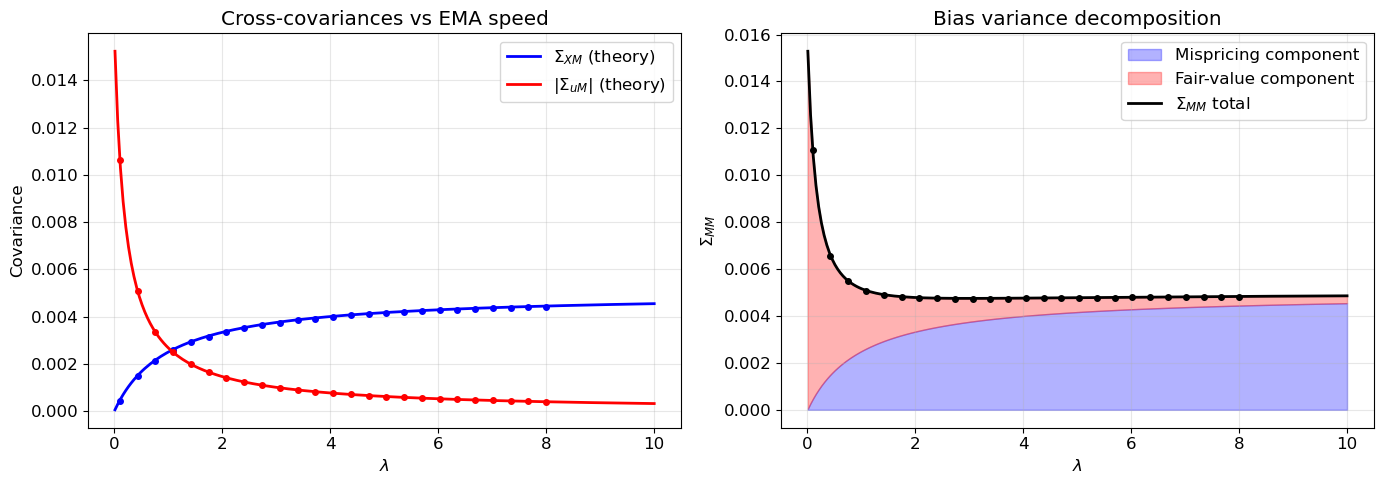

In [3]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-ema-moments
#| fig-cap: 'Stationary moments of the two-scale OU + EMA system vs $\lambda$. Theory (lines) matches Monte Carlo (dots). Left: $\Sigma_{XM}$ (unchanged from Part 3) and $|\Sigma_{uM}|$ (new, from fair-value tracking). Right: $\Sigma_{MM}$ decomposes into mispricing and fair-value components.'
theta, sigma, theta_v, sigma_v = 1.0, 0.10, 0.2, 0.08
T, dt, n_paths = 100, 1 / 252, 5_000
lam_scan = np.linspace(0.1, 8.0, 25)

# Theory
lam_fine = np.linspace(0.01, 10.0, 200)
SigXM_th = lam_fine * sigma**2 / (2 * theta * (theta + lam_fine))
SiguM_th = -sigma_v**2 / (2 * (theta_v + lam_fine))
SigMM_th = lam_fine * sigma**2 / (2 * theta * (theta + lam_fine)) + sigma_v**2 / (2 * (theta_v + lam_fine))

# MC
SigXM_mc, SiguM_mc, SigMM_mc = [], [], []
for lam in lam_scan:
    sim_rng = np.random.default_rng(42)
    u, X, M = simulate_two_scale_ou(theta, theta_v, sigma, sigma_v, lam, T, dt, n_paths, rng=sim_rng)
    half = X.shape[1] // 2
    SigXM_mc.append(np.mean(X[:, half:] * M[:, half:]))
    SiguM_mc.append(np.mean(u[:, half:] * M[:, half:]))
    SigMM_mc.append(np.mean(M[:, half:]**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lam_fine, SigXM_th, 'b-', lw=2, label=r'$\Sigma_{XM}$ (theory)')
axes[0].plot(lam_scan, SigXM_mc, 'bo', ms=4)
axes[0].plot(lam_fine, np.abs(SiguM_th), 'r-', lw=2, label=r'$|\Sigma_{uM}|$ (theory)')
axes[0].plot(lam_scan, np.abs(SiguM_mc), 'ro', ms=4)
axes[0].set_xlabel(r'$\lambda$')
axes[0].set_ylabel('Covariance')
axes[0].set_title('Cross-covariances vs EMA speed')
axes[0].legend()

# Components of Sigma_MM
comp_X = lam_fine * sigma**2 / (2 * theta * (theta + lam_fine))
comp_v = sigma_v**2 / (2 * (theta_v + lam_fine))
axes[1].fill_between(lam_fine, 0, comp_X, alpha=0.3, color='blue', label='Mispricing component')
axes[1].fill_between(lam_fine, comp_X, comp_X + comp_v, alpha=0.3, color='red', label='Fair-value component')
axes[1].plot(lam_fine, SigMM_th, 'k-', lw=2, label=r'$\Sigma_{MM}$ total')
axes[1].plot(lam_scan, SigMM_mc, 'ko', ms=4)
axes[1].set_xlabel(r'$\lambda$')
axes[1].set_ylabel(r'$\Sigma_{MM}$')
axes[1].set_title('Bias variance decomposition')
axes[1].legend()

plt.tight_layout()
plt.show()

# Modified Sharpe Ratio

## Expected PnL rate

The two-term PnL decomposes as:

- **Mean-reversion profit**: $\theta\,(\Sigma_{XX} - \Sigma_{XM}) = \dfrac{\theta\sigma^2}{2(\theta + \lambda)}$ (identical to Part 3)
- **Fair-value drift loss**: $-\theta_v\,(\Sigma_{uX} - \Sigma_{uM}) = -\dfrac{\theta_v\sigma_v^2}{2(\theta_v + \lambda)}$ (new)

$$\boxed{\mathbb{E}[\text{PnL rate}] = \frac{\theta\sigma^2}{2(\theta + \lambda)} - \frac{\theta_v\sigma_v^2}{2(\theta_v + \lambda)}.}$$

The two terms have a striking parallel structure: each is the product of the reversion speed, the noise variance, and an EMA penalty factor. The first is profit (from correctly trading mispricing); the second is loss (from mistakenly trading fair-value movements as if they were mispricing). When the EMA is slow ($\lambda$ small), the first term is large but the second is also large: the trader profits from mispricing but loses on fair-value tracking. When the EMA is fast ($\lambda$ large), both terms shrink.

## Viability condition

The expected PnL is positive for some $\lambda$ if and only if

$$\boxed{\theta\sigma^2 > \theta_v\sigma_v^2.}$$

Equivalently, $\theta/\theta_v > \rho^2$. The strategy is viable only when the mispricing signal ($\theta\sigma^2$, reflecting both the speed and magnitude of mean reversion) exceeds the fair-value noise ($\theta_v\sigma_v^2$). This is the two-scale analogue of the signal-to-noise condition.

## Quadratic variation and Sharpe ratio

Since $dW \perp dW^v$, the QV rate is:

$$\text{QV rate} = (\sigma^2 + \sigma_v^2)\left[\frac{\sigma^2}{2(\theta + \lambda)} + \frac{\sigma_v^2}{2(\theta_v + \lambda)}\right].$$

The asymptotic Sharpe ratio follows:

$$\boxed{\mathrm{SR}_\infty(\lambda) = \frac{\dfrac{\theta\sigma^2}{2(\theta+\lambda)} - \dfrac{\theta_v\sigma_v^2}{2(\theta_v+\lambda)}}{\sqrt{(\sigma^2 + \sigma_v^2)\left[\dfrac{\sigma^2}{2(\theta+\lambda)} + \dfrac{\sigma_v^2}{2(\theta_v+\lambda)}\right]}}.}$$

Setting $\sigma_v = 0$ recovers the Part 3 result $\theta/\sqrt{2(\theta + \lambda)}$.

## Optimal EMA speed

The optimal $\lambda^*$ balances two opposing forces: slower EMA preserves mispricing profit but incurs large fair-value tracking losses; faster EMA reduces fair-value losses but also destroys the mispricing signal. The optimal $\lambda^*$ satisfies a nonlinear equation and must be found numerically in general; @fig-sr-ema-two-scale shows the SR as a function of $\lambda$ for several parameter configurations.

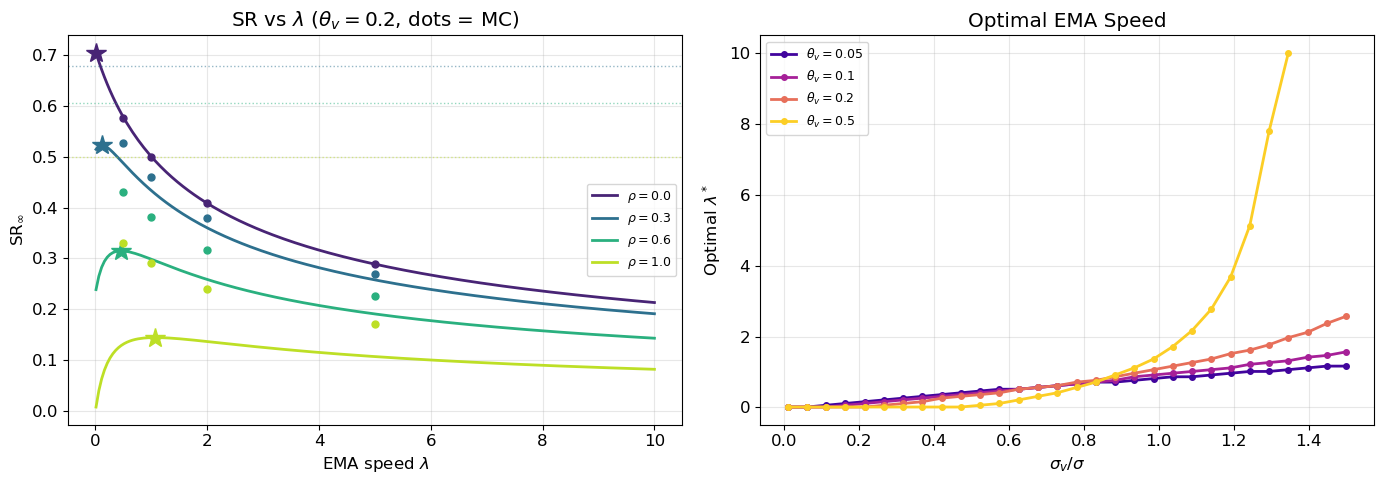

In [4]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-ema-two-scale
#| fig-cap: 'Sharpe ratio vs EMA speed under two-scale OU model. Left: SR($\lambda$) for several $\sigma_v$ values with $\theta_v = 0.2$. Stars mark optimal $\lambda^*$. Dashed lines show irreducible SR. Right: optimal $\lambda^*$ vs $\sigma_v/\sigma$ for several $\theta_v$ values.'
theta, sigma = 1.0, 0.10
T, dt, n_paths = 100, 1 / 252, 3_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SR(lambda) for several sigma_v values
theta_v_fixed = 0.2
sigma_v_ratios = [0.0, 0.3, 0.6, 1.0]
lam_range = np.linspace(0.01, 10.0, 200)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(sigma_v_ratios)))

for rho, c in zip(sigma_v_ratios, colors):
    sv = rho * sigma
    sr_th = np.array([sr_ema_two_scale(theta, theta_v_fixed, sigma, sv, l) for l in lam_range])
    axes[0].plot(lam_range, sr_th, color=c, lw=2, label=f'$\\rho = {rho}$')

    # Optimal lambda
    if sr_th.max() > 0:
        best_idx = np.argmax(sr_th)
        axes[0].plot(lam_range[best_idx], sr_th[best_idx], '*', ms=15, color=c, zorder=5)

    # MC verification at a few points
    lam_mc_pts = [0.5, 1.0, 2.0, 5.0]
    for lam_pt in lam_mc_pts:
        sim_rng = np.random.default_rng(42)
        u, X, M = simulate_two_scale_ou(theta, theta_v_fixed, sigma, sv, lam_pt, T, dt, n_paths, rng=sim_rng)
        sr_mc = compute_sr_mc(u, X, M, sigma, sv, dt, T)
        axes[0].plot(lam_pt, sr_mc, 'o', ms=5, color=c, zorder=5)

    # Irreducible SR
    if rho > 0:
        sr_irr = sr_perfect_info(theta, sigma, sv)
        axes[0].axhline(sr_irr, color=c, ls=':', lw=1, alpha=0.5)

axes[0].set_xlabel(r'EMA speed $\lambda$')
axes[0].set_ylabel(r'$\mathrm{SR}_\infty$')
axes[0].set_title(f'SR vs $\\lambda$ ($\\theta_v = {theta_v_fixed}$, dots = MC)')
axes[0].legend(fontsize=9)

# Right: optimal lambda* vs rho for several theta_v
theta_v_values = [0.05, 0.1, 0.2, 0.5]
rho_scan_opt = np.linspace(0.01, 1.5, 30)
tv_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(theta_v_values)))

for tv, tc in zip(theta_v_values, tv_colors):
    opt_lams = []
    for rho in rho_scan_opt:
        sv = rho * sigma
        sr_curve = np.array([sr_ema_two_scale(theta, tv, sigma, sv, l) for l in lam_range])
        if sr_curve.max() > 0:
            opt_lams.append(lam_range[np.argmax(sr_curve)])
        else:
            opt_lams.append(np.nan)
    axes[1].plot(rho_scan_opt, opt_lams, 'o-', ms=4, lw=2, color=tc, label=f'$\\theta_v = {tv}$')

axes[1].set_xlabel(r'$\sigma_v / \sigma$')
axes[1].set_ylabel(r'Optimal $\lambda^*$')
axes[1].set_title('Optimal EMA Speed')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Kalman Filter Preview

The EMA is a one-parameter filter that treats $p_t$ as a single signal. The Kalman-Bucy filter for the two-scale OU system does better by exploiting the known dynamics: it separately tracks $v_t$ and $X_t$ using the full state-space structure.

In state-space form, the state $(u_t, X_t)^\top$ has dynamics $dx = Fx\, dt + G\, dW$ and the observation is $dp_t = Cx\, dt + H\, dW$ (same Brownian motions, creating correlated state and observation noise). The steady-state error covariance $P_\infty$ satisfies the continuous-time algebraic Riccati equation, and the Kalman gain $K$ provides the optimal linear filter.

The KF produces separate estimates $\hat{u}_t$ and $\hat{X}_t$ with gains that automatically balance the two timescales — fast mean reversion in $X$ vs slow reversion in $u$. The residual estimation error $\text{Var}(X_t - \hat{X}_t)$ is smaller than the EMA's error $\text{Var}(X_t - \tilde{X}_t + M_t)$ because the KF does not conflate the two sources of variation.

@fig-kalman-comparison shows the SR achieved by the Kalman filter vs the EMA at optimal $\lambda^*$. The gap represents the cost of using a naive one-parameter filter rather than the optimal two-parameter filter.

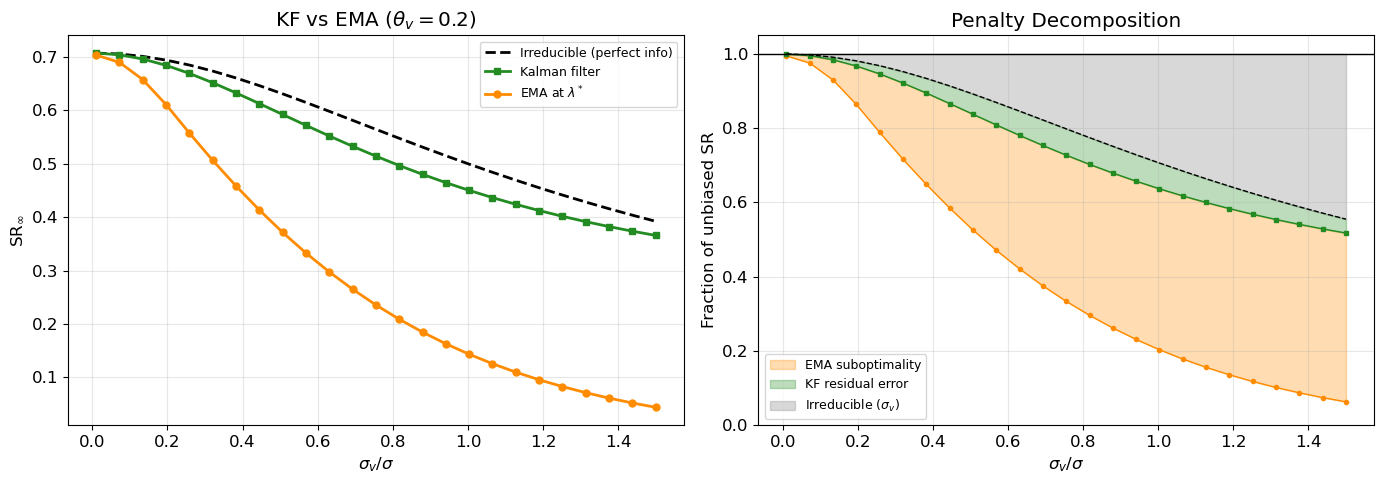

In [5]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-kalman-comparison
#| fig-cap: 'Kalman filter vs EMA comparison. Left: SR of KF (via Riccati solution) and EMA (at optimal $\lambda^*$) vs $\sigma_v/\sigma$. The gap grows with fair-value noise. Right: penalty decomposition into three layers: irreducible, KF-residual, and EMA-suboptimality.'
theta, sigma = 1.0, 0.10
theta_v = 0.2
rho_scan_kf = np.linspace(0.01, 1.5, 25)
lam_range_kf = np.linspace(0.01, 15.0, 300)

sr_irr_list, sr_kf_list, sr_ema_opt_list = [], [], []

for rho in rho_scan_kf:
    sv = rho * sigma

    # Irreducible
    sr_irr_list.append(sr_perfect_info(theta, sigma, sv))

    # KF: solve Riccati, get residual error variance for X
    P, K = kalman_steady_state(theta, theta_v, sigma, sv)
    # P[1,1] is Var(X - X_hat), P[0,0] is Var(u - u_hat)
    var_X_err = P[1, 1]
    # The KF estimate of X has error M_kf with Var = var_X_err
    # And Cov(M_kf, X) = ? For the KF, the error is uncorrelated with the estimate (orthogonality)
    # So the SR formula: E[PnL] uses the covariance structure.
    # For a proper SR, we'd need the full covariance of the KF state.
    # Approximation: treat KF error as independent bias with variance P[1,1]
    # SR_kf ≈ sqrt(theta/2) / sqrt(1 + P[1,1]/s_inf^2) / sqrt(1 + sigma_v^2/sigma^2)
    # But this double-counts. The correct formula:
    # E[PnL] = theta * (s_inf^2 - Cov(X, M_kf))  (mispricing part, M_kf is KF error)
    # For the KF, the innovation is orthogonal to the estimate, so Cov(X, X-X_hat) = Var(X-X_hat)
    # Therefore Cov(X_hat, X) = Var(X) - Var(X-X_hat) = s_inf^2 - P[1,1]
    # And Cov(M_kf, X) = Cov(X - X_hat, X) = P[1,1]
    # So E[PnL from MR] = theta*(s_inf^2 - P[1,1])
    s_inf2 = sigma**2 / (2 * theta)
    # Fair-value part: E[(X - M_kf)(-theta_v u)] = -theta_v Cov(X_hat, u)
    # Since X_hat = X - (X-X_hat), Cov(X_hat, u) = Cov(X, u) - Cov(X-X_hat, u) = 0 - P[0,1]
    # So fair-value loss = -theta_v * (0 - (-P[0,1])) = -theta_v * P[0,1]  ...need sign care
    # Actually: position is -(X_hat), PnL from dv: -X_hat * dv
    # E[-X_hat * (-theta_v u)] = theta_v Cov(X_hat, u) = theta_v * (Cov(X,u) - P[0,1])
    # = theta_v * (0 - P[0,1]) = -theta_v * P[0,1]

    # With P from Riccati:
    e_pnl_kf = theta * (s_inf2 - P[1, 1]) - theta_v * P[0, 1]

    # QV: (sigma^2 + sigma_v^2) * E[X_hat^2]
    # E[X_hat^2] = Var(X_hat) = s_inf^2 - P[1,1]  (X_hat = X - error, Var(X_hat) = Var(X) - Var(error))
    var_Xhat = s_inf2 - P[1, 1]
    qv_kf = (sigma**2 + sv**2) * max(var_Xhat, 1e-12)

    sr_kf = e_pnl_kf / np.sqrt(qv_kf) if e_pnl_kf > 0 and qv_kf > 0 else 0.0
    sr_kf_list.append(sr_kf)

    # Optimal EMA SR
    sr_ema_curve = np.array([sr_ema_two_scale(theta, theta_v, sigma, sv, l) for l in lam_range_kf])
    sr_ema_opt_list.append(sr_ema_curve.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rho_scan_kf, sr_irr_list, 'k--', lw=2, label='Irreducible (perfect info)')
axes[0].plot(rho_scan_kf, sr_kf_list, 's-', ms=5, lw=2, color='forestgreen', label='Kalman filter')
axes[0].plot(rho_scan_kf, sr_ema_opt_list, 'o-', ms=5, lw=2, color='darkorange', label=r'EMA at $\lambda^*$')
axes[0].set_xlabel(r'$\sigma_v / \sigma$')
axes[0].set_ylabel(r'$\mathrm{SR}_\infty$')
axes[0].set_title(f'KF vs EMA ($\\theta_v = {theta_v}$)')
axes[0].legend(fontsize=9)

# Right: penalty decomposition
sr_unbiased = np.sqrt(theta / 2)
irr_arr = np.array(sr_irr_list)
kf_arr = np.array(sr_kf_list)
ema_arr = np.array(sr_ema_opt_list)

axes[1].fill_between(rho_scan_kf, ema_arr / sr_unbiased, kf_arr / sr_unbiased,
                      alpha=0.3, color='darkorange', label='EMA suboptimality')
axes[1].fill_between(rho_scan_kf, kf_arr / sr_unbiased, irr_arr / sr_unbiased,
                      alpha=0.3, color='forestgreen', label='KF residual error')
axes[1].fill_between(rho_scan_kf, irr_arr / sr_unbiased, 1.0,
                      alpha=0.3, color='gray', label='Irreducible ($\\sigma_v$)')
axes[1].plot(rho_scan_kf, ema_arr / sr_unbiased, 'o-', ms=3, color='darkorange', lw=1)
axes[1].plot(rho_scan_kf, kf_arr / sr_unbiased, 's-', ms=3, color='forestgreen', lw=1)
axes[1].plot(rho_scan_kf, irr_arr / sr_unbiased, 'k--', lw=1)
axes[1].axhline(1.0, color='black', lw=1)
axes[1].set_xlabel(r'$\sigma_v / \sigma$')
axes[1].set_ylabel('Fraction of unbiased SR')
axes[1].set_title('Penalty Decomposition')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Discussion

The introduction of a time-varying fair value fundamentally changes the mean-reversion strategy's performance landscape. Where Parts 1–5 dealt with a single source of estimation penalty — the trader's inability to observe the static fair value — Part 6 introduces a **hierarchy of three penalties**:

1. **Irreducible penalty** from $\sigma_v$: even with perfect information, the trader's position is exposed to orthogonal fair-value noise, reducing the Sharpe ratio by $1/\sqrt{1 + \rho^2}$ (@fig-irreducible).

2. **Filtering penalty**: when the trader cannot observe $v_t$ and $X_t$ separately, the optimal linear filter (Kalman-Bucy) incurs residual estimation error whose cost is captured by the Riccati solution.

3. **EMA suboptimality penalty**: using a one-parameter EMA rather than the optimal two-parameter Kalman filter further degrades performance, with the gap growing in $\sigma_v/\sigma$ (@fig-kalman-comparison).

The analytical results have clean parallel structure. The expected PnL decomposes into two terms — mispricing profit $\theta\sigma^2/(2(\theta+\lambda))$ minus fair-value tracking loss $\theta_v\sigma_v^2/(2(\theta_v+\lambda))$ — with identical functional dependence on their respective parameters (@fig-sr-ema-two-scale). The viability condition $\theta\sigma^2 > \theta_v\sigma_v^2$ provides a sharp criterion: the mispricing signal must dominate the fair-value noise for the strategy to be profitable at any EMA speed.

The Lyapunov solution for the 3D system $(u_t, X_t, M_t)$ extends Part 3's results cleanly. All six entries have closed forms, the Part 3 cross-covariance $\Sigma_{XM}$ is unchanged (because $u$ and $X$ are independent), and $\Sigma_{MM}$ decomposes additively into mispricing and fair-value tracking errors (@fig-ema-moments). The new covariance $\Sigma_{uM} < 0$ captures the EMA's lag in tracking fair-value movements.

The practical implications are significant. The optimal EMA speed $\lambda^*$ now depends on $\theta_v/\theta$ and $\sigma_v/\sigma$, not just $\theta$. When fair-value noise is substantial, the trader faces an irreducible loss that no estimation procedure can eliminate — only external information about $v_t$ (from predictors, fundamentals, or other assets) can reduce the effective $\sigma_v$. This motivates the predictor-based nowcasting framework that we develop in the next post, where the trader uses observable factors $Z_t$ to form a conditional estimate of $v_t$, effectively reducing $\sigma_v^2$ to $\sigma_{v|Z}^2$ and tightening the irreducible bound.